## Urszula Michalska, Natalia Rogalska


In [2]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import time

In [3]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [4]:
lgbm = lgb.LGBMClassifier()

param_grid = {
    'max_depth': [-1, 3, 5, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [200, 400, 600],
    'subsample': [0.6, 0.7, 0.85, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.85, 1.0],
    'lambda_l1': [0.0, 0.1, 1, 5],
    'lambda_l2': [0.0, 0.1, 1, 5],
    'num_leaves': [15, 31, 63, 127],
    'min_data_in_leaf' : [10,20,50],
    'min_sum_hessian_in_leaf' : [1e-3, 1e-2, 0.1],
    'feature_fraction' : [0.6, 0.8, 1.0],
    'bagging_fraction' : [0.6, 0.8, 1.0],
    'bagging_freq' : [0,1,5],
    'class_weight': [{0: 1.0, 1: 3}]


}

start = time.perf_counter()

lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

end = time.perf_counter()
print(f"Elapsed time: {end - start:.6f} seconds")



c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.1, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.1
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=0.85 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=

In [5]:
start = time.perf_counter()

lgbm_best = lgb.LGBMClassifier(**lgbm.best_params_)
lgbm_best.fit(X_train,y_train)
lgbm_best.score(X_test,y_test)

end = time.perf_counter()
print(f"Elapsed time: {end - start:.6f} seconds")

c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.1, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.1
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=0.85 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=

In [24]:
y_pred_best = lgbm_best.predict(X_test)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.85 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.001, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.001
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=0.6 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


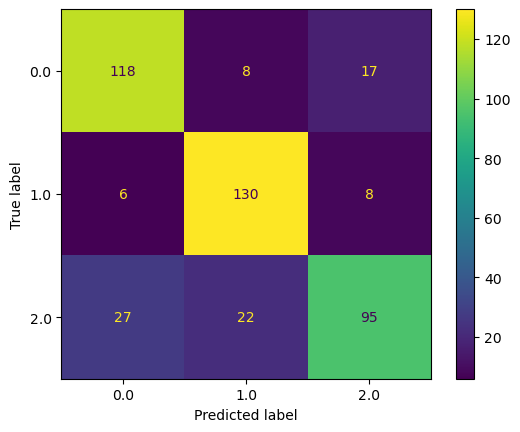

In [25]:
cm = confusion_matrix(y_test, y_pred_best, labels=lgbm_best.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lgbm_best.classes_)
disp.plot()

In [26]:
class_report = classification_report(y_test, y_pred_best)
print("Classification Report:")
print(class_report)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best)}")

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.83      0.80       143
         1.0       0.81      0.90      0.86       144
         2.0       0.79      0.66      0.72       144

    accuracy                           0.80       431
   macro avg       0.80      0.80      0.79       431
weighted avg       0.80      0.80      0.79       431

Accuracy: 0.7958236658932715


In [36]:
test_final = pd.read_csv("test_final.csv")
id = pd.read_csv("id.csv")

preds_to_eval = lgbm_best.predict(test_final)

#final_preds = pd.Series(preds_to_eval)
#final_preds.to_csv("final_preds.csv", index = False)
preds_to_eval = pd.Series(preds_to_eval)

preds_to_eval = preds_to_eval.replace(2.0,"lived")
preds_to_eval = preds_to_eval.replace(1.0,"euthanized")
preds_to_eval = preds_to_eval.replace(0.0,"died")

#preds_to_eval = pd.concat([id, test_final])

#pd.DataFrame(preds_to_eval, columns=["id","outcome"]).to_csv("final_preds.csv", index = False)
final_df = pd.concat([id, preds_to_eval.rename("outcome")], axis=1)
final_df.to_csv("final_preds.csv", index=False)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=0.1, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=0.1
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=0.85 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


In [31]:
id.head()

,id
0,1235
1,1236
2,1237
3,1238
4,1239


In [37]:
x = pd.read_csv("final_preds.csv")
x.head()

,id,outcome
0,1235,lived
1,1236,died
2,1237,lived
3,1238,euthanized
4,1239,lived


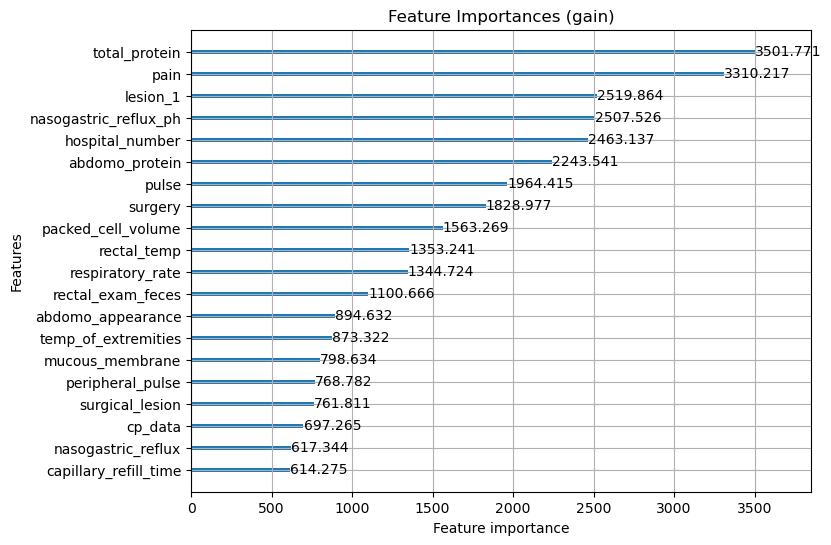

In [38]:
lgb.plot_importance(
    lgbm_best,
    importance_type='gain',   # 'gain' albo 'split'
    max_num_features=20,
    figsize=(8, 6)
)

plt.title("Feature Importances (gain)")
plt.show()